In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from tqdm import tqdm
import matplotlib.pyplot as plt

def binary_neighborhood_selection(X):
    """
    Stability selection with bootstrapped sparse logistic regression (LogisticRegressionCV).

    Args:
        X: (N, P) binary matrix (entries should be 0 or 1).
        n_bootstraps: number of bootstrap iterations.
        freq_threshold: minimum frequency for edge inclusion [0.0–1.0].
        cv: number of folds for LogisticRegressionCV.

    Returns:
        edge_freq: (P, P) matrix of edge selection frequencies.
        adj_stable: (P, P) binary matrix of stable edges.
    """
    N, P = X.shape
    edge_counts = np.zeros((P, P))
    n_bootstraps = 100

    for b in tqdm(range(n_bootstraps)):
        X_b = resample(X, replace=True, n_samples=N)

        for j in range(P):
            y = X_b[:, j]
            X_others = np.delete(X_b, j, axis=1)
            feature_indices = [i for i in range(P) if i != j]

            # Logistic regression with L1 regularization and cross-validation
            model = LogisticRegressionCV(
                penalty='l1',
                solver='saga',
                cv=10,
                scoring='neg_log_loss',
                max_iter=10000,
                fit_intercept=False,
                Cs=10,  # number of inverse regularization values
                tol=1e-4,
            )

            try:
                model.fit(X_others, y)
                coefs = model.coef_[0]  # shape (P - 1,)
            except Exception as e:
                # Catch numerical issues (e.g. perfect separation) and skip
                coefs = np.zeros(P - 1)

            for idx, coef in zip(feature_indices, coefs):
                if coef != 0:
                    edge_counts[j, idx] += 1

    edge_freq = edge_counts / n_bootstraps
    return np.maximum(edge_freq, edge_freq.T)

def simulate_sparse_ising(P=20, N=100, edge_prob=0.1, beta_range=(0.5, 1.5), seed=None, burn_in=100):
    """
    Simulates binary data from a sparse Ising model using Gibbs sampling.

    Args:
        P: number of variables.
        N: number of samples.
        edge_prob: probability of edge between nodes.
        beta_range: strength range for non-zero interactions.
        seed: random seed.
        burn_in: number of burn-in steps for Gibbs sampler.

    Returns:
        X: (N, P) binary samples from the model.
        theta: (P, P) true interaction matrix.
        adj_matrix: binary adjacency matrix (ground truth graph).
    """
    rng = np.random.default_rng(seed)
    theta = np.zeros((P, P))

    # Randomly create sparse symmetric interaction matrix
    for i in range(P):
        for j in range(i + 1, P):
            if rng.random() < edge_prob:
                beta = rng.uniform(*beta_range)
                theta[i, j] = theta[j, i] = beta * rng.choice([-1, 1])  # +/- edge

    adj_matrix = (theta != 0).astype(int)

    # Gibbs sampling
    X = np.zeros((N, P), dtype=int)
    x = rng.integers(0, 2, size=P)  # Initial state

    for t in range(N + burn_in):
        for i in range(P):
            h_i = np.dot(theta[i], x)
            prob = 1 / (1 + np.exp(-h_i))
            x[i] = rng.binomial(1, prob)

        if t >= burn_in:
            X[t - burn_in] = x.copy()

    return X, theta, adj_matrix

100%|██████████| 100/100 [17:56<00:00, 10.76s/it]


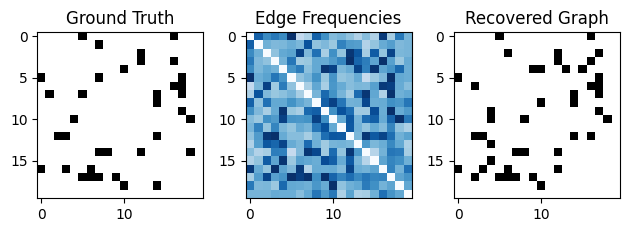

In [ ]:
X, theta_true, adj_true = simulate_sparse_ising(P=20, N=200, edge_prob=0.1, seed=42, burn_in=500)
edge_freq = binary_neighborhood_selection(X)

plt.subplot(1, 3, 1)
plt.imshow(adj_true, cmap='Greys')
plt.title("Ground Truth")

plt.subplot(1, 3, 2)
plt.imshow(edge_freq, cmap='Blues')
plt.title("Edge Frequencies")

plt.subplot(1, 3, 3)
adj_est = (edge_freq >= 0.90).astype(int)
plt.imshow(adj_est, cmap='Greys')
plt.title("Recovered Graph")

plt.tight_layout()
plt.show()

In [ ]:
X, theta_true, adj_true = simulate_sparse_ising(P=300, N=200, edge_prob=0.1, seed=42, burn_in=500)
edge_freq = binary_neighborhood_selection(X)

plt.subplot(1, 3, 1)
plt.imshow(adj_true, cmap='Greys')
plt.title("Ground Truth")

plt.subplot(1, 3, 2)
plt.imshow(edge_freq, cmap='Blues')
plt.title("Edge Frequencies")

plt.subplot(1, 3, 3)
adj_est = (edge_freq >= 0.90).astype(int)
plt.imshow(adj_est, cmap='Greys')
plt.title("Recovered Graph")

plt.tight_layout()
plt.show()